In [129]:
!pip install PyMySQL
!pip install pandas
!pip install sqlalchemy
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [130]:
from sqlalchemy import create_engine
import pandas as pd 
from sqlalchemy.exc import OperationalError
from sqlalchemy.types import VARCHAR

In [131]:
df= pd.DataFrame({'Name':['Jack', 'Joe', 'Jay', 'John'],
                  'ID':['A001', 'A002', 'A005', 'A006'],
                  'Language':[5, 6, 7, 8]}).set_index('Name')

df

,ID,Language
Name,,
Jack,A001,5
Joe,A002,6
Jay,A005,7
John,A006,8


In [132]:
connection_config={
    'user':'root',
    'password':'admin1234',
    'host':'127.0.0.1',
    'port':'3306',
    'database':'3rd'
}

#Define a dictionary that used to connect the database with the correct configuration


In [133]:
engine = create_engine(
    'mysql+pymysql://{user}:{password}@{host}:{port}/{database}'.format(**connection_config)
)

#Use create_engine to define an Engine var, then sub in the connection_config

In [134]:
df.to_sql('test_table01',con= engine, if_exists='replace', dtype={'Name': VARCHAR(255)})

#test_table01= the file name to be create
#if exists: replace= replace, fail= error, append= add at the back

4

In [135]:
df2= pd.DataFrame({'Name':['Jack', 'Joe', 'Jay', 'John'],
                  'ID':['A001', 'A002', 'A005', 'A006'],
                  'Math':[1, 2, 3, 4]}).set_index('Name')

df2

,ID,Math
Name,,
Jack,A001,1
Joe,A002,2
Jay,A005,3
John,A006,4


In [136]:
df2.to_sql('test_table02',con= engine, if_exists='replace', dtype={'Name': VARCHAR(255)})

4

In [137]:
#Input local file into MYSql database

df25= pd.read_csv('C:/Users/MSI Modern/Downloads/XAUUSD_Daily.csv')
df25

,DATE,OPEN,HIGH,LOW,CLOSE,VOL
0,2024.09.02,2502.34,2507.18,2489.94,2499.46,0
1,2024.09.03,2499.89,2506.18,2473.39,2492.86,0
2,2024.09.04,2493.05,2500.15,2471.77,2495.44,0
3,2024.09.05,2495.24,2523.31,2493.72,2516.63,0
4,2024.09.06,2516.84,2529.08,2485.02,2497.61,0
5,2024.09.09,2497.09,2507.04,2485.44,2506.22,0
6,2024.09.10,2506.19,2518.32,2500.02,2516.54,0
7,2024.09.11,2516.55,2528.93,2500.85,2511.35,0
8,2024.09.12,2511.97,2559.98,2510.90,2558.60,0
9,2024.09.13,2558.54,2585.92,2556.61,2578.38,0


In [138]:
#Setting certain row as Index
#df25= df25.set_index('Unnamed: 0')

In [139]:
df25.to_sql('test_table03', con=engine, if_exists= 'replace')

35

In [140]:
df = pd.read_sql("SHOW TABLES;", con=engine)
print(df)

  Tables_in_3rd
0    test_table
1  test_table01
2  test_table02
3  test_table03


In [141]:
#Use Python to obtain data from database
#Connection_config2 and engine2, is to extract from another database called 'sql_invoicing'

connection_config2={
    'user':'root',
    'password':'admin1234',
    'host':'127.0.0.1',
    'port':'3306',
    'database':'sql_invoicing'
}

engine2=  create_engine(
    'mysql+pymysql://{user}:{password}@{host}:{port}/{database}'.format(**connection_config2)
)

df3= pd.read_sql(sql= 'SELECT * From sql_invoicing.invoices;', con= engine2)

df3

#Pd.read_sql, turned data into dataframe, sql= the clause used to write SQL code, con= connection information 

,invoice_id,number,client_id,invoice_total,payment_total,invoice_date,due_date,payment_date
0,1,91-953-3396,2,101.79,0.00,2019-03-09,2019-03-29,None
1,2,03-898-6735,5,175.32,8.18,2019-06-11,2019-07-01,2019-02-12
2,3,20-228-0335,5,147.99,0.00,2019-07-31,2019-08-20,None
3,4,56-934-0748,3,152.21,0.00,2019-03-08,2019-03-28,None
4,5,87-052-3121,5,169.36,0.00,2019-07-18,2019-08-07,None
5,6,75-587-6626,1,157.78,74.55,2019-01-29,2019-02-18,2019-01-03
6,7,68-093-9863,3,133.87,0.00,2019-09-04,2019-09-24,None
7,8,78-145-1093,1,189.12,0.00,2019-05-20,2019-06-09,None
8,9,77-593-0081,5,172.17,0.00,2019-07-09,2019-07-29,None
9,10,48-266-1517,1,159.50,0.00,2019-06-30,2019-07-20,None


In [142]:
df3.sort_values(by='client_id', ascending= False)

#Sorting

,invoice_id,number,client_id,invoice_total,payment_total,invoice_date,due_date,payment_date
8,9,77-593-0081,5,172.17,0.00,2019-07-09,2019-07-29,None
11,13,41-666-1035,5,135.01,87.44,2019-06-25,2019-07-15,2019-01-26
2,3,20-228-0335,5,147.99,0.00,2019-07-31,2019-08-20,None
4,5,87-052-3121,5,169.36,0.00,2019-07-18,2019-08-07,None
15,18,52-269-9803,5,180.17,42.77,2019-05-23,2019-06-12,2019-01-08
1,2,03-898-6735,5,175.32,8.18,2019-06-11,2019-07-01,2019-02-12
3,4,56-934-0748,3,152.21,0.00,2019-03-08,2019-03-28,None
6,7,68-093-9863,3,133.87,0.00,2019-09-04,2019-09-24,None
14,17,33-615-4694,3,126.38,68.10,2019-07-30,2019-08-19,2019-01-15
12,15,55-105-9605,3,167.29,80.31,2019-11-25,2019-12-15,2019-01-15


<BarContainer object of 4 artists>

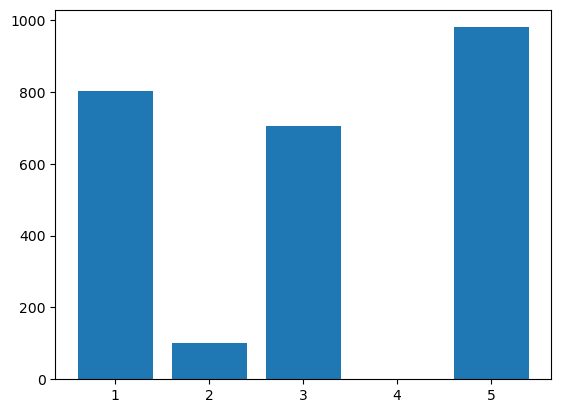

In [143]:
# Visualizing data using Python code

import matplotlib.pyplot as plt
#import japanize_matplotlib 
%matplotlib inline

df3_graph= df3.pivot_table(values= 'invoice_total', index= 'client_id', aggfunc= 'sum')

x= df3_graph. index
y= df3_graph['invoice_total']

plt.bar(x,y)

In [144]:
#Using Lambda or programming to define logic or Masking

f= lambda x: '150 and above' if x >150 else ' 150 and below'
df3['Logic 1']= df3['invoice_total'].map(f)
df3

,invoice_id,number,client_id,invoice_total,payment_total,invoice_date,due_date,payment_date,Logic 1
0,1,91-953-3396,2,101.79,0.00,2019-03-09,2019-03-29,None,150 and below
1,2,03-898-6735,5,175.32,8.18,2019-06-11,2019-07-01,2019-02-12,150 and above
2,3,20-228-0335,5,147.99,0.00,2019-07-31,2019-08-20,None,150 and below
3,4,56-934-0748,3,152.21,0.00,2019-03-08,2019-03-28,None,150 and above
4,5,87-052-3121,5,169.36,0.00,2019-07-18,2019-08-07,None,150 and above
5,6,75-587-6626,1,157.78,74.55,2019-01-29,2019-02-18,2019-01-03,150 and above
6,7,68-093-9863,3,133.87,0.00,2019-09-04,2019-09-24,None,150 and below
7,8,78-145-1093,1,189.12,0.00,2019-05-20,2019-06-09,None,150 and above
8,9,77-593-0081,5,172.17,0.00,2019-07-09,2019-07-29,None,150 and above
9,10,48-266-1517,1,159.50,0.00,2019-06-30,2019-07-20,None,150 and above


In [145]:
#More detailed version of SQL code(+Where clause)

df4= pd.read_sql(sql= 'SELECT * From sql_invoicing.invoices WHERE client_id= 3;', con= engine2)
df4

,invoice_id,number,client_id,invoice_total,payment_total,invoice_date,due_date,payment_date
0,4,56-934-0748,3,152.21,0.00,2019-03-08,2019-03-28,None
1,7,68-093-9863,3,133.87,0.00,2019-09-04,2019-09-24,None
2,11,20-848-0181,3,126.15,0.03,2019-01-07,2019-01-27,2019-01-11
3,15,55-105-9605,3,167.29,80.31,2019-11-25,2019-12-15,2019-01-15
4,17,33-615-4694,3,126.38,68.10,2019-07-30,2019-08-19,2019-01-15


In [146]:
#Adding Python code into SQL clause 
#Using the combination of for loop and where clause to obtain certain client_id's 


client_id_py= [1, 2, 3, 4, 5]

for i in client_id_py:
    sql_query= f'SELECT * FROM sql_invoicing.invoices WHERE client_id= {i}'
    df5= pd.read_sql(sql=sql_query,con= engine2)
    print(f"Client No. {i}'s order")
    print(df5)

#For loop here= Run the list(client_id_py), after the where clause then running it sequentially

Client No. 1's order
   invoice_id       number  client_id  invoice_total  payment_total  \
0           6  75-587-6626          1         157.78          74.55   
1           8  78-145-1093          1         189.12           0.00   
2          10  48-266-1517          1         159.50           0.00   
3          16  10-451-8824          1         162.02           0.00   
4          19  83-559-4105          1         134.47           0.00   

  invoice_date    due_date payment_date  
0   2019-01-29  2019-02-18   2019-01-03  
1   2019-05-20  2019-06-09         None  
2   2019-06-30  2019-07-20         None  
3   2019-03-30  2019-04-19         None  
4   2019-11-23  2019-12-13         None  
Client No. 2's order
   invoice_id       number  client_id  invoice_total  payment_total  \
0           1  91-953-3396          2         101.79            0.0   

  invoice_date    due_date payment_date  
0   2019-03-09  2019-03-29         None  
Client No. 3's order
   invoice_id       number  cli

In [147]:
#Show all the table in the connection

df5 = pd.read_sql("SHOW TABLES;", con=engine)
df5

,Tables_in_3rd
0,test_table
1,test_table01
2,test_table02
3,test_table03


In [148]:
#Show which data base is connecting at the moment 

df6 = pd.read_sql("SELECT DATABASE() AS connected_db;", con=engine)
print("The database currently connecting：", df6['connected_db'][0])

The database currently connecting： 3rd


In [171]:
sql_query = "SELECT * FROM sql_invoicing.invoices"
df7 = pd.read_sql(sql_query, con=engine)

df7

,invoice_id,number,client_id,invoice_total,payment_total,invoice_date,due_date,payment_date
0,1,91-953-3396,2,101.79,0.00,2019-03-09,2019-03-29,None
1,2,03-898-6735,5,175.32,8.18,2019-06-11,2019-07-01,2019-02-12
2,3,20-228-0335,5,147.99,0.00,2019-07-31,2019-08-20,None
3,4,56-934-0748,3,152.21,0.00,2019-03-08,2019-03-28,None
4,5,87-052-3121,5,169.36,0.00,2019-07-18,2019-08-07,None
5,6,75-587-6626,1,157.78,74.55,2019-01-29,2019-02-18,2019-01-03
6,7,68-093-9863,3,133.87,0.00,2019-09-04,2019-09-24,None
7,8,78-145-1093,1,189.12,0.00,2019-05-20,2019-06-09,None
8,9,77-593-0081,5,172.17,0.00,2019-07-09,2019-07-29,None
9,10,48-266-1517,1,159.50,0.00,2019-06-30,2019-07-20,None


In [173]:
df7.to_excel("invoices_export.xlsx", index=False)

In [ ]:
#Reference video: https://www.youtube.com/watch?v=fYqjHspuvd0